In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

Aqui solo estamos diciendo con que vamos a trabajar la parte 1

In [3]:
# activos
tickers = ["MELI", "REGN", "B"]

# fechas
train_start = "2024-09-17"
train_end = "2025-09-16"

test_start = "2025-09-17"
test_end = "2026-09-17"

# capital inicial
capital = 1_000_000

# tasa libre de riesgo esta utilizada de acuerdo a Treassury de EEU
rf = 0.036

# dias bursatiles
dias = 252

# parametros del algoritmo genetico
population_size = 100
generations = 200
mutation_rate = 0.20
elite_size = 5

# para obtener los mismos resultados aleatorios
np.random.seed(42)

2. descargar precios y calcular rendimeintos  Obteniendolos con pct_change()


In [4]:
# descargamos un dia extra porque yfinance no incluye la fecha "end"
end_download = "2026-09-18"

data = yf.download(
    tickers,
    start=train_start,
    end=end_download,
    auto_adjust=True,
    progress=False
)

# tomamos los precios de cierre ajustados
prices = data["Close"]

# ordenamos las columnas
prices = prices[tickers]

# eliminamos filas con datos faltantes
prices = prices.dropna()

# calculamos rendimientos simples diarios
returns = prices.pct_change().dropna()

returns.head()

Ticker,MELI,REGN,B
Date,,,
2024-09-18,0.013682,-0.006924,-0.020508
2024-09-19,0.003215,0.009993,0.008474
2024-09-20,-0.002678,-0.004486,0.007415
2024-09-23,-0.000532,-0.046331,-0.008341
2024-09-24,0.003981,-0.042125,0.010886


3. Separara Train y Test

**Train** sirve para encontrar los pesos (W) DE MELI, REGN Y B  **Test** sirve para  ver que habria ocurrido despues, utilizando esos mismos precios 

In [5]:
train = returns.loc[train_start:train_end]

test = returns.loc[test_start:test_end]

print("Observaciones TRAIN:", len(train))
print("Observaciones TEST:", len(test))

print("\nTRAIN:")
print(train.index.min(), "a", train.index.max())

print("\nTEST:")
print(test.index.min(), "a", test.index.max())

Observaciones TRAIN: 249
Observaciones TEST: 252

TRAIN:
2024-09-18 00:00:00 a 2025-09-16 00:00:00

TEST:
2025-09-17 00:00:00 a 2026-09-17 00:00:00


4.  **Funciones financieras** sacamos medias y covarianzas utilizando  unicamente TRAIN: 

las funciones que se vana  realizar a continuacion  representan lo siguiente: 

 

$R_p = w^\top \mu$

$\sigma_p = \sqrt{w^\top \Sigma w}$

$Sharpe = \frac{R_p - R_f}{\sigma_p}$




 

In [6]:
mean_returns = train.mean()
cov_matrix = train.cov()


def portfolio_return(weights):
    
    annual_return = np.dot(weights, mean_returns) * dias
    
    return annual_return


def portfolio_volatility(weights):
    
    variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    
    volatility = np.sqrt(variance) * np.sqrt(dias)
    
    return volatility


def sharpe_ratio(weights):
    
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    
    sharpe = (ret - rf) / vol
    
    return sharpe

5. Semivarianza
Ahora medimos solamente los rendimeintos negativos. la logica coincide  en calcular los rendimientos del portafolio  y quedarnos con las desviaciones que estas por debajo de la **frontera de MARKOWITS** que en nuestro caso es 0

In [7]:
# medimos los rendimienot negativos 
def semivariance(weights):
    
    portfolio_returns = np.dot(train, weights)
    
    downside = np.minimum(portfolio_returns, 0)
    
    semi = np.mean(downside ** 2)
    
    return semi

6. Algoritmo genettico.
Aqui empieza realmente nuestra heuristica

In [ ]:
# ALGORITMO GENETICO    
def crear_poblacion():
    
    poblacion = []
    
    for i in range(population_size):
        
        weights = np.random.random(3)
        
        # hacemos que los pesos sumen 1
        weights = weights / weights.sum()
        
        poblacion.append(weights)
    
    return np.array(poblacion)
## CADA INDIVIDUO ES UN PORTAFOLIO


# seleccion 
def seleccionar(poblacion, fitness):
    
    candidatos = np.random.choice(len(poblacion), 3, replace=False)
    
    mejor = candidatos[np.argmax(fitness[candidatos])]
    
    return poblacion[mejor]
## ELIJIMOS TRES PORTAFOLIOS ALEATORIOS  Y DEJAMOS QUE 
# PASE EL QUE TENGA MEJOR FITNESS


# Crossover, mezclamos dos portafolios
def crossover(padre1, padre2):
    
    alpha = np.random.random()
    
    hijo = alpha * padre1 + (1 - alpha) * padre2
    
    return hijo

# mutacion 
def mutacion(weights):
    
    if np.random.random() < mutation_rate:
        
        cambio = np.random.normal(0, 0.05, 3)
        
        weights = weights + cambio
        
        # no permitimos pesos negativos
        weights = np.clip(weights, 0, 1)
        
        # hacemos que vuelvan a sumar 1
        weights = weights / weights.sum()
    
    return weights

Ahora junatmos  todo, basicamente aqui es el corazon de todo lo anterior.

In [9]:
def algoritmo_genetico(fitness_function):
    
    poblacion = crear_poblacion()
    
    history = []
    
    for generation in range(generations):
        
        # calculamos fitness
        fitness = np.array([
            fitness_function(weights)
            for weights in poblacion
        ])
        
        # ordenamos de mejor a peor
        orden = np.argsort(fitness)[::-1]
        
        poblacion = poblacion[orden]
        fitness = fitness[orden]
        
        # guardamos el mejor resultado
        history.append(fitness[0])
        
        # conservamos los mejores
        nueva_poblacion = list(poblacion[:elite_size])
        
        # creamos nuevos individuos
        while len(nueva_poblacion) < population_size:
            
            padre1 = seleccionar(poblacion, fitness)
            padre2 = seleccionar(poblacion, fitness)
            
            hijo = crossover(padre1, padre2)
            hijo = mutacion(hijo)
            
            nueva_poblacion.append(hijo)
        
        poblacion = np.array(nueva_poblacion)
    
    
    # calculamos fitness una ultima vez
    fitness = np.array([
        fitness_function(weights)
        for weights in poblacion
    ])
    
    mejor = poblacion[np.argmax(fitness)]
    
    return mejor, history

7. Econtrar Maximo de Sharpe 

In [10]:
# ENCONTAR MAXIMO DE SHARPE 
weights_sharpe, history_sharpe = algoritmo_genetico(
    sharpe_ratio)

print("Pesos Máximo Sharpe:")
print(weights_sharpe)

print("\nSharpe:")
print(sharpe_ratio(weights_sharpe))

for ticker, weight in zip(tickers, weights_sharpe):
    print(ticker, round(weight * 100, 2), "%")


Pesos Máximo Sharpe:
[2.14946500e-01 9.31791811e-18 7.85053500e-01]

Sharpe:
1.2245759613351699
MELI 21.49 %
REGN 0.0 %
B 78.51 %


8. MINIMA SEMIVARIANZA 
es importante recordar nuetra restriccion, pues no queremos minimizar el riesgo a costa de obtener cualquier rendimiento , primero calculamos el rendimiento del portafolio **equiponderado**

In [11]:
#minima semivarianza de acuerdoi a nuestro perfìl "No queremos minimizar el riesgo a costa de obtener cualquier rendimeinto"
equal_weights = np.array([1/3, 1/3, 1/3])

target_return = portfolio_return(equal_weights)

print("Target return:", target_return)



# ahora hacemos nuestro fitness 
def fitness_semivariance(weights):
    
    ret = portfolio_return(weights)
    semi = semivariance(weights)
    
    # penalizamos si no alcanza el rendimiento minimo
    if ret < target_return:
        return -1000
    
    # como el algoritmo maximiza fitness,
    # usamos el negativo de la semivarianza
    return -semi

# ahora si optimizamos 
weights_semi, history_semi = algoritmo_genetico(
    fitness_semivariance
)

print("Pesos Mínima Semivarianza:")

for ticker, weight in zip(tickers, weights_semi):
    print(ticker, round(weight * 100, 2), "%")



Target return: 0.008601664389558401
Pesos Mínima Semivarianza:
MELI 29.75 %
REGN 20.98 %
B 49.28 %


 Si el portafolio no alcanza el rendimeinto minimo exigido , recibe un **fitness** muy mal .


 Ahora veremos la composicion de nuestros tres portafolios.
 1. **Maximo de Sharpe**
 2. **Minima semivarianza**
 3. **Equiponderado**

In [12]:
#nuestro tres portafolio 
portfolios = {
    "Maximo Sharpe": weights_sharpe,
    "Minima Semivarianza": weights_semi,
    "Equiponderado": equal_weights
}
portfolios 

# YA TENEMOS EXACTAMENTE LAS TRES ESTRATEGIAS QUE QUERIAMOS COMPROBAR 

{'Maximo Sharpe': array([2.14946500e-01, 9.31791811e-18, 7.85053500e-01]),
 'Minima Semivarianza': array([0.29748215, 0.20976234, 0.49275552]),
 'Equiponderado': array([0.33333333, 0.33333333, 0.33333333])}

10. convertimos pesos a dólares 

In [13]:
# convertir pesos a dolares 
for name, weights in portfolios.items():
    
    print("\n", name)
    
    for ticker, weight in zip(tickers, weights):
        
        allocation = weight * capital
        
        print(
            ticker,
            round(weight * 100, 2), "%",
            " = $",
            round(allocation, 2))


 Maximo Sharpe
MELI 21.49 %  = $ 214946.5
REGN 0.0 %  = $ 0.0
B 78.51 %  = $ 785053.5

 Minima Semivarianza
MELI 29.75 %  = $ 297482.15
REGN 20.98 %  = $ 209762.34
B 49.28 %  = $ 492755.52

 Equiponderado
MELI 33.33 %  = $ 333333.33
REGN 33.33 %  = $ 333333.33
B 33.33 %  = $ 333333.33


11 Backtesting
Ahora utilizamos  **TEST**, que hasta ahora no lo habiamos utilizado hasta optimizar.

In [14]:
# es necesario sacar el backtesting 
portfolio_test_returns = pd.DataFrame()

for name, weights in portfolios.items():
    
    portfolio_test_returns[name] = np.dot(test, weights)

    # y calculamos como habra  valido nuestro millon 
    portfolio_values = capital * (
    1 + portfolio_test_returns
).cumprod()

portfolio_values.tail()


,Maximo Sharpe,Minima Semivarianza,Equiponderado
247,1.381494e+06,1.299870e+06,1.251730e+06
248,1.350907e+06,1.286399e+06,1.246961e+06
249,1.346760e+06,1.269400e+06,1.223730e+06
250,1.344751e+06,1.269599e+06,1.224963e+06
251,1.370757e+06,1.288485e+06,1.240507e+06


12. Funcion para las metricas 

aqui estamos utilizando MAR=0(rendimeinto minimo aceptablel) es decir consideramos desfavorable cualquier dia en el que el portafolio tenga un rendimeinto negativo 

In [15]:
# funcion para las metricas 
def metricas(returns):
    
    cumulative_return = (1 + returns).prod() - 1
    
    annual_return = returns.mean() * dias
    
    volatility = returns.std() * np.sqrt(dias)
    
    sharpe = (annual_return - rf) / volatility
    
    
    # downside
    downside_returns = np.minimum(returns, 0)
    
    downside_deviation = (
        np.sqrt(np.mean(downside_returns ** 2))
        * np.sqrt(dias)
    )
    
    
    # Sortino con MAR = 0
    sortino = annual_return / downside_deviation
    
    
    # drawdown
    wealth = (1 + returns).cumprod()
    
    running_max = wealth.cummax()
    
    drawdown = wealth / running_max - 1
    
    max_drawdown = drawdown.min()
    
    
    return {
        "Rendimiento": cumulative_return,
        "Rendimiento anual": annual_return,
        "Volatilidad": volatility,
        "Sharpe": sharpe,
        "Downside": downside_deviation,
        "Sortino": sortino,
        "Max Drawdown": max_drawdown
    }

Tabla final 



In [16]:
resultados = []

for name, weights in portfolios.items():
    
    m = metricas(portfolio_test_returns[name])
    
    final_value = portfolio_values[name].iloc[-1]
    
    
    resultados.append({
        
        "Estrategia": name,
        
        "Peso MELI": weights[0],
        "Peso REGN": weights[1],
        "Peso Barrick": weights[2],
        
        "USD MELI": weights[0] * capital,
        "USD REGN": weights[1] * capital,
        "USD Barrick": weights[2] * capital,
        
        **m,
        
        "Capital Final": final_value,
        "Ganancia USD": final_value - capital
    })


resultados = pd.DataFrame(resultados)

resultados

,Estrategia,Peso MELI,Peso REGN,Peso Barrick,USD MELI,USD REGN,USD Barrick,Rendimiento,Rendimiento anual,Volatilidad,Sharpe,Downside,Sortino,Max Drawdown,Capital Final,Ganancia USD
0,Maximo Sharpe,0.214947,9.317918e-18,0.785053,214946.500294,9.317918e-12,785053.499706,0.370757,0.397238,0.404115,0.893899,0.281864,1.409324,-0.295746,1.370757e+06,370756.941102
1,Minima Semivarianza,0.297482,2.097623e-01,0.492756,297482.149799,2.097623e+05,492755.515056,0.288485,0.298912,0.301576,0.871793,0.204742,1.459945,-0.260575,1.288485e+06,288485.116099
2,Equiponderado,0.333333,3.333333e-01,0.333333,333333.333333,3.333333e+05,333333.333333,0.240507,0.250430,0.264615,0.810347,0.176046,1.422523,-0.254061,1.240507e+06,240507.156895


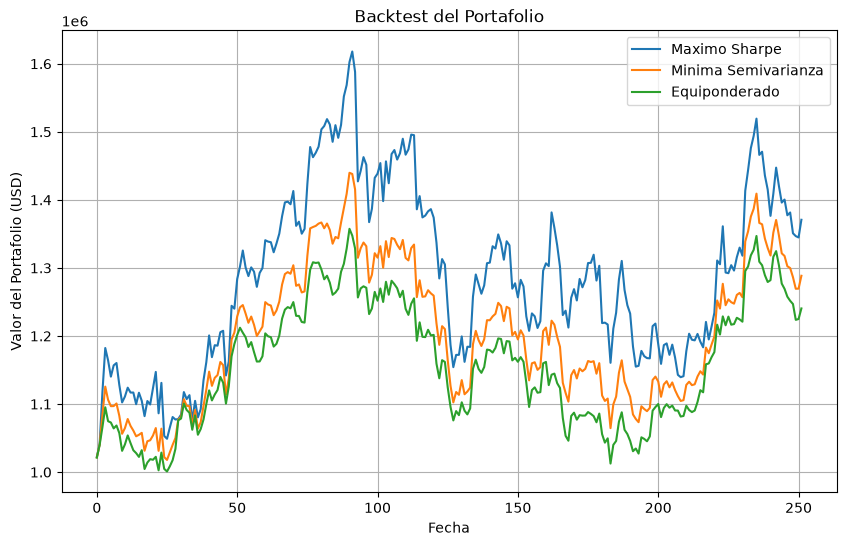

In [17]:
# Garfica del millon de dolares 
plt.figure(figsize=(10, 6))

for name in portfolio_values.columns:
    plt.plot(
        portfolio_values.index,
        portfolio_values[name],
        label=name
    )

plt.title("Backtest del Portafolio")
plt.xlabel("Fecha")
plt.ylabel("Valor del Portafolio (USD)")
plt.legend()
plt.grid()

plt.show()

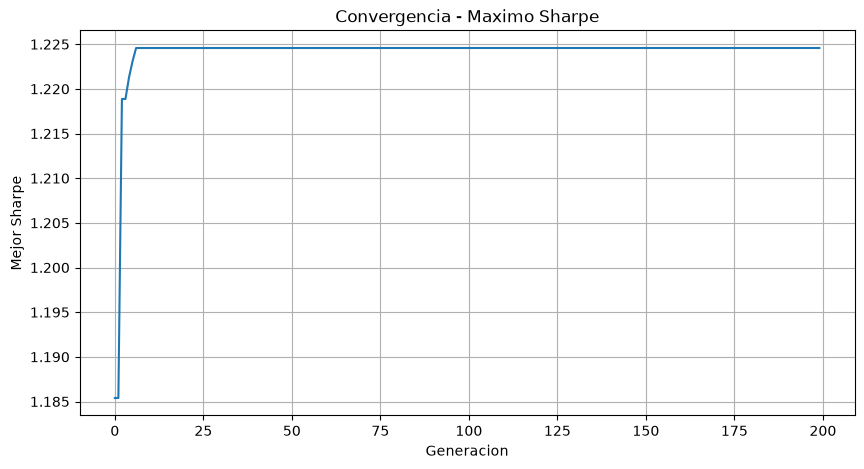

In [18]:
# convergencia del algoritmo genetivo 
plt.figure(figsize=(10, 5))

plt.plot(history_sharpe)

plt.title("Convergencia - Maximo Sharpe")
plt.xlabel("Generacion")
plt.ylabel("Mejor Sharpe")

plt.grid()

plt.show()

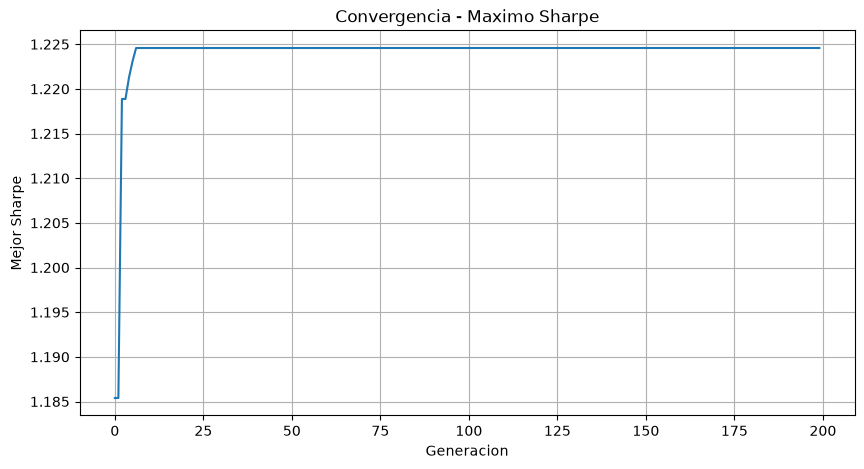

In [19]:
# convergencia de semivarianza 

plt.figure(figsize=(10, 5))

plt.plot(history_sharpe)

plt.title("Convergencia - Maximo Sharpe")
plt.xlabel("Generacion")
plt.ylabel("Mejor Sharpe")

plt.grid()

plt.show()


## FASE 2: TRADING SIMPLE CON MEDIA MÓVIL
Optimización heurística mediante Algoritmo Genético

1. DATOS DE ENTRENAMIENTO

In [20]:
# ====================================================================
# FASE 2: TRADING SIMPLE CON MEDIA MÓVIL
# Optimización heurística mediante Algoritmo Genético
# ====================================================================
# ====================================================================
# 1. DATOS DE ENTRENAMIENTO
# ====================================================================

# Usamos únicamente los precios del periodo TRAIN
train_prices = prices.loc[train_start:train_end]


# Límites de las ventanas de la media móvil
MIN_WINDOW = 5
MAX_WINDOW = 200

LÓGICA DE TRADING

In [21]:
def simular_trading_sma(precios, ventana):
    """
    Simula una estrategia de trading basada en el cruce
    del precio con una Media Móvil Simple (SMA).

    Compra cuando el precio cruza la SMA hacia arriba.
    Venta cuando el precio cruza la SMA hacia abajo.

    Se utiliza la posición del día anterior para evitar
    look-ahead bias.
    """

    # Asegurar que la ventana sea un entero válido
    ventana = int(np.clip(ventana, MIN_WINDOW, MAX_WINDOW))

    # Calcular la Media Móvil Simple
    sma = precios.rolling(window=ventana).mean()
    

    # ------------------------------------------------------------
    # Detectar cruces
    # ------------------------------------------------------------

    # Cruce positivo: el precio pasa de estar debajo
    # a estar por encima de la SMA
    cruce_compra = (
        (precios > sma) &
        (precios.shift(1) <= sma.shift(1))
    )

    # Cruce negativo: el precio pasa de estar encima
    # a estar por debajo de la SMA
    cruce_venta = (
        (precios < sma) &
        (precios.shift(1) >= sma.shift(1))
    )

    # ------------------------------------------------------------
    # Crear posición
    # ------------------------------------------------------------

   # ------------------------------------------------------------
    # Crear posición (VERSIÓN VECTORIZADA OPTIMIZADA)
    # ------------------------------------------------------------
    # Inicializamos con NaN para poder propagar la señal anterior
    posiciones = pd.Series(np.nan, index=precios.index)
    
    # Asignamos 1 en cruces de compra y 0 en cruces de venta
    posiciones.loc[cruce_compra] = 1
    posiciones.loc[cruce_venta] = 0
    
    # ffill() rellena los NaN hacia adelante (mantiene la posición hasta que haya otra señal)
    # fillna(0) asegura que empecemos sin posición (0) antes de la primera señal
    posiciones = posiciones.ffill().fillna(0)

    # ------------------------------------------------------------
    # Rendimientos diarios
    # ------------------------------------------------------------

    retornos_diarios = precios.pct_change()

    # Utilizamos la posición del día anterior
    # para evitar utilizar información futura
    retornos_estrategia = (
        posiciones.shift(1) * retornos_diarios
    )

    return retornos_estrategia.fillna(0)

FUNCIÓN PARA CALCULAR EL RENDIMIENTO DEL PORTAFOLIO

In [22]:
def calcular_rendimiento_trading(pesos, ventanas):
    """
    Calcula los rendimientos diarios del portafolio
    utilizando los pesos y ventanas de SMA proporcionados.
    """

    # Serie donde acumularemos los rendimientos
    retornos_portafolio = pd.Series(
        0.0,
        index=train_prices.index
    )

    # Evaluar cada activo
    for i, ticker in enumerate(tickers):

        # Simular la estrategia para el activo
        retornos_activo = simular_trading_sma(
            train_prices[ticker],
            ventanas[i]
        )

        # Agregar al portafolio según su peso
        retornos_portafolio += (
            retornos_activo * pesos[i]
        )

    return retornos_portafolio

FUNCIÓN FITNESS

In [23]:
def fitness_trading(cromosoma):
    """
    Evalúa cada individuo del Algoritmo Genético.

    Cromosoma:

    [peso_1, peso_2, peso_3,
     ventana_1, ventana_2, ventana_3]

    La función busca maximizar el rendimiento
    considerando el riesgo del portafolio.
    """

    # ------------------------------------------------------------
    # Extraer pesos
    # ------------------------------------------------------------

    pesos = np.array(cromosoma[:3], dtype=float)

    # Evitar división entre cero
    if pesos.sum() <= 0:
        return -1000

    # Normalizar pesos para que sumen 100%
    pesos = pesos / pesos.sum()

    # ------------------------------------------------------------
    # Extraer ventanas
    # ------------------------------------------------------------

    ventanas = np.array(
        cromosoma[3:],
        dtype=int
    )

    ventanas = np.clip(
        ventanas,
        MIN_WINDOW,
        MAX_WINDOW
    )

    # ------------------------------------------------------------
    # Calcular rendimientos
    # ------------------------------------------------------------

    retornos_portafolio = calcular_rendimiento_trading(
        pesos,
        ventanas
    )

    # ------------------------------------------------------------
    # Rendimiento promedio anualizado
    # ------------------------------------------------------------

    rendimiento_promedio = (
        retornos_portafolio.mean() * dias
    )

    # ------------------------------------------------------------
    # Riesgo promedio anualizado
    # ------------------------------------------------------------

    riesgo_promedio = (
        retornos_portafolio.std() * np.sqrt(dias)
    )

    # Penalizar estrategias sin riesgo / sin operaciones
    if riesgo_promedio <= 0:
        return -1000

    # ------------------------------------------------------------
    # Función objetivo
    # ------------------------------------------------------------

    # Se busca obtener el mayor rendimiento
    # considerando el riesgo asumido.
    sharpe = (
        rendimiento_promedio - rf
    ) / riesgo_promedio

    return sharpe

CREAR POBLACIÓN INICIAL

In [24]:

def crear_poblacion_fase2():

    poblacion = []

    for _ in range(population_size):

        # --------------------------------------------------------
        # Pesos del capital
        # --------------------------------------------------------

        pesos = np.random.random(3)

        # Normalizar para que sumen 100%
        pesos = pesos / pesos.sum()

        # --------------------------------------------------------
        # Ventanas de las medias móviles
        # --------------------------------------------------------

        ventanas = np.random.randint(
            MIN_WINDOW,
            MAX_WINDOW + 1,
            3
        )

        # Crear cromosoma
        cromosoma = np.concatenate(
            (pesos, ventanas)
        )

        poblacion.append(cromosoma)

    return np.array(poblacion)

MUTACIÓN


In [25]:
def mutacion_fase2(cromosoma):

    if np.random.random() < mutation_rate:

        # --------------------------------------------------------
        # Mutación de los pesos
        # --------------------------------------------------------

        cambio_pesos = np.random.normal(
            0,
            0.05,
            3
        )

        pesos = np.clip(
            cromosoma[:3] + cambio_pesos,
            0,
            1
        )

        # Evitar que todos sean cero
        if pesos.sum() == 0:
            pesos = np.ones(3)

        # Normalizar
        pesos = pesos / pesos.sum()

        # --------------------------------------------------------
        # Mutación de las ventanas
        # --------------------------------------------------------

        cambio_ventanas = np.random.randint(
            -10,
            11,
            3
        )

        ventanas = cromosoma[3:] + cambio_ventanas

        ventanas = np.clip(
            ventanas,
            MIN_WINDOW,
            MAX_WINDOW
        )

        # Crear nuevo cromosoma
        cromosoma = np.concatenate(
            (pesos, ventanas)
        )

    return cromosoma

CROSSOVER


In [26]:
def crossover_fase2(padre1, padre2):

    hijo = np.zeros(6)

    # ------------------------------------------------------------
    # Crossover de pesos
    # ------------------------------------------------------------

    alpha = np.random.random()

    hijo[:3] = (
        alpha * padre1[:3]
        + (1 - alpha) * padre2[:3]
    )

    # Normalizar pesos
    hijo[:3] = hijo[:3] / hijo[:3].sum()

    # ------------------------------------------------------------
    # Crossover de ventanas
    # ------------------------------------------------------------

    for i in range(3, 6):

        if np.random.random() < 0.5:
            hijo[i] = padre1[i]
        else:
            hijo[i] = padre2[i]

    return hijo

ALGORITMO GENÉTICO

In [27]:

def algoritmo_genetico_fase2():

    # Crear población inicial
    poblacion = crear_poblacion_fase2()

    # Guardar evolución del mejor fitness
    history = []

    # ------------------------------------------------------------
    # Generaciones
    # ------------------------------------------------------------

    for generation in range(generations):

        # Evaluar fitness de cada individuo
        fitness = np.array([
            fitness_trading(individuo)
            for individuo in poblacion
        ])

        # Ordenar de mejor a peor
        orden = np.argsort(fitness)[::-1]

        poblacion = poblacion[orden]
        fitness = fitness[orden]

        # Guardar el mejor resultado
        history.append(fitness[0])

        # Mantener los mejores individuos
        nueva_poblacion = list(
            poblacion[:elite_size]
        )

        # --------------------------------------------------------
        # Crear nuevos individuos
        # --------------------------------------------------------

        while len(nueva_poblacion) < population_size:

            # Seleccionar padres
            padre1 = seleccionar(
                poblacion,
                fitness
            )

            padre2 = seleccionar(
                poblacion,
                fitness
            )

            # Crossover
            hijo = crossover_fase2(
                padre1,
                padre2
            )

            # Mutación
            hijo = mutacion_fase2(hijo)

            # Agregar hijo
            nueva_poblacion.append(hijo)

        # Actualizar población
        poblacion = np.array(nueva_poblacion)

    # ------------------------------------------------------------
    # Obtener mejor individuo final
    # ------------------------------------------------------------

    fitness_final = np.array([
        fitness_trading(individuo)
        for individuo in poblacion
    ])

    mejor_individuo = poblacion[
        np.argmax(fitness_final)
    ]

    return mejor_individuo, history

EJECUTAR OPTIMIZACIÓN

In [28]:
mejor_cromosoma_f2, history_f2 = (
    algoritmo_genetico_fase2()
)

# =============================
# EXTRAER RESULTADOS
# =============================

# Pesos óptimos
pesos_optimos = mejor_cromosoma_f2[:3]

pesos_optimos = (
    pesos_optimos
    / pesos_optimos.sum()
)

# Ventanas óptimas
ventanas_optimas = (
    mejor_cromosoma_f2[3:]
    .astype(int)
)

# Rendimientos finales
retornos_optimos = calcular_rendimiento_trading(
    pesos_optimos,
    ventanas_optimas
)

# Rendimiento anualizado
rendimiento_optimo = (
    retornos_optimos.mean() * dias
)

# Riesgo anualizado
riesgo_optimo = (
    retornos_optimos.std() * np.sqrt(dias)
)

# Sharpe
sharpe_optimo = (
    rendimiento_optimo - rf
) / riesgo_optimo

MOSTRAR RESULTADOS

In [29]:

print("=" * 60)
print("RESULTADOS TRADING SIMPLE")
print("=" * 60)

print("\nParámetros óptimos:")

for i, ticker in enumerate(tickers):

    print(
        f"{ticker}: "
        f"Capital = {pesos_optimos[i] * 100:.2f}% "
        f"(${pesos_optimos[i] * capital:,.2f}) | "
        f"SMA = {ventanas_optimas[i]} días"
    )

print("\nMétricas del portafolio:")
print(
    f"Rendimiento promedio anualizado: "
    f"{rendimiento_optimo * 100:.2f}%"
)

print(
    f"Riesgo promedio anualizado: "
    f"{riesgo_optimo * 100:.2f}%"
)

print(
    f"Sharpe Ratio: "
    f"{sharpe_optimo:.4f}"
)

RESULTADOS TRADING SIMPLE

Parámetros óptimos:
MELI: Capital = 14.53% ($145,289.25) | SMA = 57 días
REGN: Capital = 0.00% ($0.00) | SMA = 155 días
B: Capital = 85.47% ($854,710.75) | SMA = 105 días

Métricas del portafolio:
Rendimiento promedio anualizado: 45.45%
Riesgo promedio anualizado: 14.37%
Sharpe Ratio: 2.9127


TABLA DE RESULTADOS

In [30]:
tabla_resultados = pd.DataFrame({
    "Activo": tickers,
    "Peso Óptimo (%)": pesos_optimos * 100,
    "Capital Inicial ($)": pesos_optimos * capital,
    "Ventana SMA (días)": ventanas_optimas
})

print("\nTabla de resultados:")
display(tabla_resultados)


Tabla de resultados:


,Activo,Peso Óptimo (%),Capital Inicial ($),Ventana SMA (días)
0,MELI,1.452893e+01,145289.253531,57
1,REGN,1.462519e-08,0.000146,155
2,B,8.547107e+01,854710.746323,105


GRÁFICA DE EVOLUCIÓN DEL ALGORITMO GENÉTICO

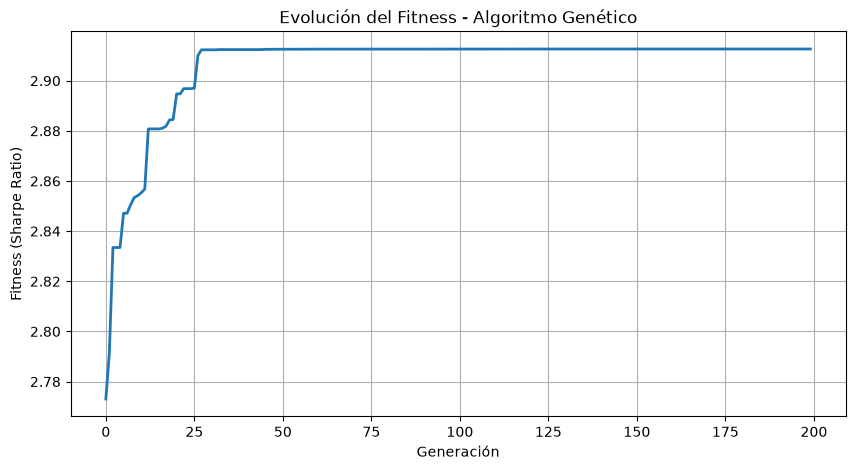

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_f2,
    linewidth=2
)

plt.title(
    "Evolución del Fitness - Algoritmo Genético"
)

plt.xlabel("Generación")
plt.ylabel("Fitness (Sharpe Ratio)")
plt.grid(True)

plt.show()

GRÁFICA DEL BALANCE DEL PORTAFOLIO

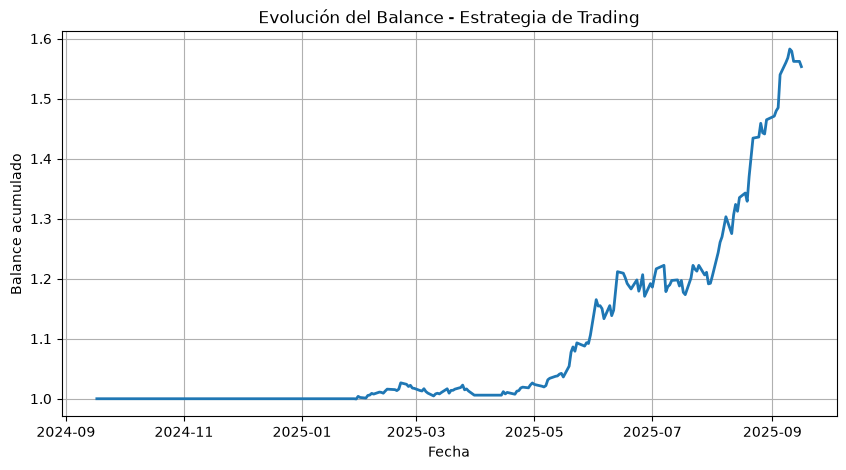

In [32]:
balance = (
    1 + retornos_optimos
).cumprod()

plt.figure(figsize=(10, 5))

plt.plot(
    balance,
    linewidth=2
)

plt.title(
    "Evolución del Balance - Estrategia de Trading"
)

plt.xlabel("Fecha")
plt.ylabel("Balance acumulado")

plt.grid(True)

plt.show()

## Datos con test 

In [33]:
# ============================================================
# VALIDACIÓN FUERA DE MUESTRA (TEST) - FASE 2
# ============================================================
# Usamos la serie completa de precios (train + test) para que
# la SMA ya esté "calentada" con los datos de entrenamiento y
# no perdamos las primeras señales del periodo de test por falta
# de historial (evita el problema de las ventanas "en blanco").

def calcular_rendimiento_trading_completo(pesos, ventanas):
    """
    Igual que calcular_rendimiento_trading, pero usa la serie
    de precios completa (train + test) en lugar de solo train.
    """
    retornos_portafolio = pd.Series(0.0, index=prices.index)

    for i, ticker in enumerate(tickers):
        retornos_activo = simular_trading_sma(
            prices[ticker],
            ventanas[i]
        )
        retornos_portafolio += retornos_activo * pesos[i]

    return retornos_portafolio


# Rendimientos diarios completos, usando los parámetros óptimos
# encontrados por el algoritmo genético (pesos_optimos, ventanas_optimas)
retornos_completos_f2 = calcular_rendimiento_trading_completo(
    pesos_optimos,
    ventanas_optimas
)

# Nos quedamos solo con el periodo TEST
retornos_test_f2 = retornos_completos_f2.loc[test_start:test_end]

print("Observaciones en TEST:", len(retornos_test_f2))

Observaciones en TEST: 252


In [34]:
# ============================================================
# MÉTRICAS EN TEST
# ============================================================
rendimiento_test_f2 = retornos_test_f2.mean() * dias
riesgo_test_f2 = retornos_test_f2.std() * np.sqrt(dias)
sharpe_test_f2 = (rendimiento_test_f2 - rf) / riesgo_test_f2

valor_final_test_f2 = capital * (1 + retornos_test_f2).prod()

print("=" * 60)
print("RESULTADOS TRADING SIMPLE - FUERA DE MUESTRA (TEST)")
print("=" * 60)
print(f"Rendimiento promedio anualizado: {rendimiento_test_f2 * 100:.2f}%")
print(f"Riesgo promedio anualizado:      {riesgo_test_f2 * 100:.2f}%")
print(f"Sharpe Ratio (test):             {sharpe_test_f2:.4f}")
print(f"Capital final (test):            ${valor_final_test_f2:,.2f}")


RESULTADOS TRADING SIMPLE - FUERA DE MUESTRA (TEST)
Rendimiento promedio anualizado: 30.29%
Riesgo promedio anualizado:      33.82%
Sharpe Ratio (test):             0.7893
Capital final (test):            $1,278,113.35


In [35]:
# ============================================================
# TABLA COMPARATIVA TRAIN vs TEST
# ============================================================
valor_final_train_f2 = capital * (1 + retornos_optimos).prod()

comparacion_f2 = pd.DataFrame({
    "Métrica": [
        "Rendimiento anualizado",
        "Riesgo anualizado",
        "Sharpe Ratio",
        "Capital final"
    ],
    "TRAIN": [
        f"{rendimiento_optimo * 100:.2f}%",
        f"{riesgo_optimo * 100:.2f}%",
        f"{sharpe_optimo:.4f}",
        f"${valor_final_train_f2:,.2f}"
    ],
    "TEST": [
        f"{rendimiento_test_f2 * 100:.2f}%",
        f"{riesgo_test_f2 * 100:.2f}%",
        f"{sharpe_test_f2:.4f}",
        f"${valor_final_test_f2:,.2f}"
    ]
})

display(comparacion_f2)

,Métrica,TRAIN,TEST
0,Rendimiento anualizado,45.45%,30.29%
1,Riesgo anualizado,14.37%,33.82%
2,Sharpe Ratio,2.9127,0.7893
3,Capital final,"$1,553,363.60","$1,278,113.35"


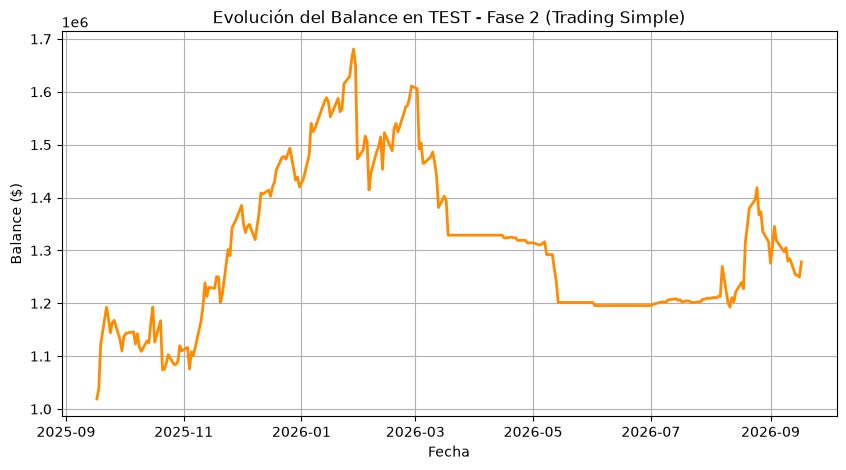

In [36]:
# ============================================================
# GRÁFICA DEL BALANCE EN TEST
# ============================================================
balance_test_f2 = (1 + retornos_test_f2).cumprod() * capital

plt.figure(figsize=(10, 5))

plt.plot(
    balance_test_f2,
    linewidth=2,
    color="darkorange"
)

plt.title("Evolución del Balance en TEST - Fase 2 (Trading Simple)")
plt.xlabel("Fecha")
plt.ylabel("Balance ($)")

plt.grid(True)
plt.show()